In [5]:
import sys
from pathlib import Path

# Adds the parent directory (project root) to the Python path
sys.path.append(str(Path.cwd().parent))

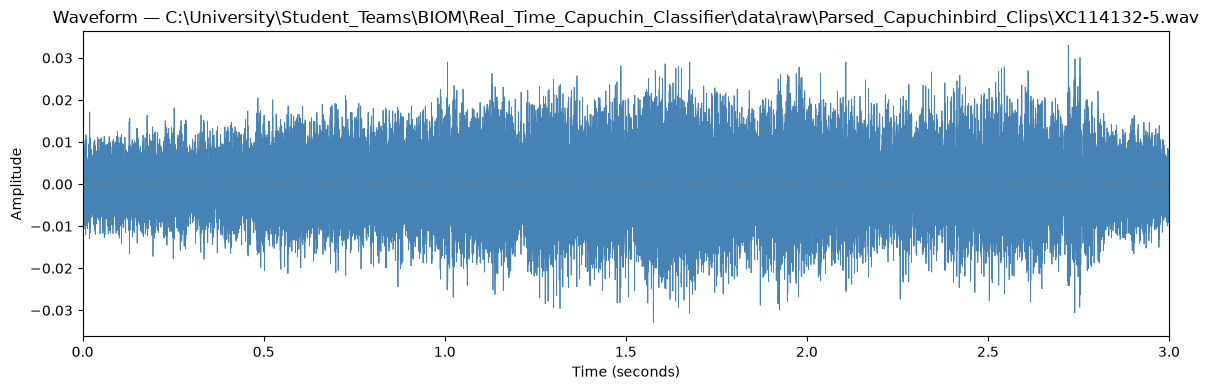

In [11]:
from pathlib import Path
import tensorflow as tf
from IPython.display import Audio, display
from glob import glob
import matplotlib.pyplot as plt
import numpy as np

CAPUCHIN_FILES = glob("C:\\University\\Student_Teams\\BIOM\\Real_Time_Capuchin_Classifier\\data\\raw\\Parsed_Capuchinbird_Clips\\*.wav")

def play_wave(file_path:str) -> None:
    """
    Plays the sound of the wave file
    """
    raw = tf.io.read_file(file_path)
    audio, sample_rate = tf.audio.decode_wav(raw, desired_channels=1)
    audio = tf.squeeze(audio, axis=1).numpy()
    sample_rate = sample_rate.numpy()

    display(Audio(data=audio, rate=sample_rate))


def plot_amplitude(file_path: str)-> None:
  """
  Function to plot the wave amplitude against time
  """
  # Load the audio using TF
  raw = tf.io.read_file(file_path)
  audio, sample_rate = tf.audio.decode_wav(raw, desired_channels=1)
  # Remove the extra dimension and convert to numpy array
  audio = tf.squeeze(audio, axis=-1).numpy()
  # Convert the smaple rate to numpy array as well
  sample_rate = sample_rate.numpy()

  # Build the time axis in seconds
  duration = len(audio) / sample_rate
  time_axis = np.linspace(0, duration, num=len(audio))

  # Plot
  plt.figure(figsize=(12, 4))
  plt.plot(time_axis, audio, color='steelblue', linewidth=0.6)
  plt.title(f"Waveform — {file_path.split('/')[-1]}")
  plt.xlabel("Time (seconds)")
  plt.ylabel("Amplitude")
  plt.xlim([0, duration])
  # plt.ylim([-1.0, 1.0])
  plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
    capuchin_file_path = CAPUCHIN_FILES[10]

    plot_amplitude(file_path=capuchin_file_path)
    play_wave(file_path=capuchin_file_path)


Time to generate spec: 0.021857799999452254


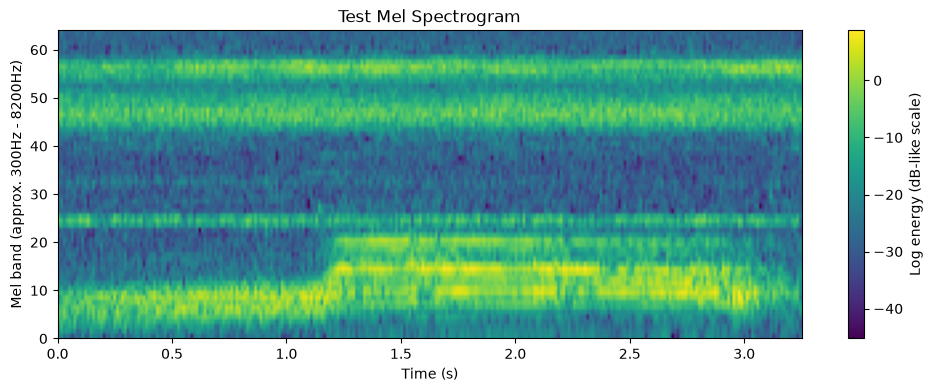

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from features.mel_spectogram_generator import MelSpectrogramGen
import time

def plot_mel_spectrogram(
    mel_spec: np.ndarray,
    gen,
    title: str = "Mel Spectrogram",
    ax=None,
):
    sr = gen.sr
    hop_length = gen.hop_length
    low_hz = gen.low_hz
    high_hz = gen.high_hz

    # --- Step 2: figure out the axis ranges ---
    n_mels, n_frames = mel_spec.shape

    # X-axis: convert "frame index" into actual seconds. Each frame
    # represents `hop_length` audio samples, and there are `sr` samples
    # per second, so: seconds_per_frame = hop_length / sr.
    duration_s = n_frames * hop_length / sr

    # --- Step 3: create the figure/axes if the caller didn't pass one in ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    img = ax.imshow(
        mel_spec,
        origin="lower",
        aspect="auto",
        extent=[0, duration_s, 0, n_mels],
        cmap="viridis",
    )

    # --- Step 5: label the axes ---
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"Mel band (approx. {low_hz:.0f}Hz - {high_hz:.0f}Hz)")
    ax.set_title(title)

    # --- Step 6: add a colorbar so viewers know what the colors mean ---
    # The values in mel_spec are in a log/decibel-like scale (from
    # generate_mel_spectogram's log10 step), so we label it as such.
    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label("Log energy (dB-like scale)")

    plt.show()

    return ax

if __name__ == "__main__":

    # Build the generator from the shared config, same as always.
    gen = MelSpectrogramGen.from_config()

    raw = tf.io.read_file(capuchin_file_path)
    audio, sample_rate = tf.audio.decode_wav(raw, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1).numpy()
    sample_rate = sample_rate.numpy()

    start = time.perf_counter()
    filtered_audio = gen.bandpass_filter(audio=audio)
    mel_spec = gen.generate_mel_spectrogram(filtered_audio)
    end = time.perf_counter()

    print(f"Time to generate spec: {end - start}")

    plot_mel_spectrogram(mel_spec, gen, title="Test Mel Spectrogram")

Time to generate spec: 0.0270767000001797


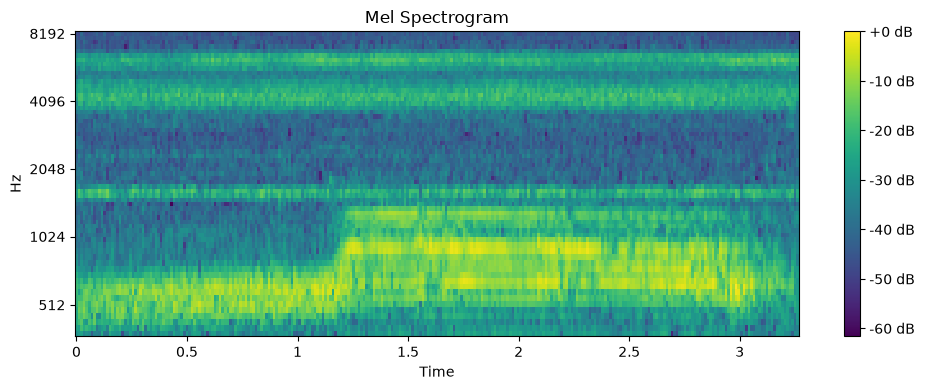

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

sr = 44100
duration = 3.0

# 2. Compute the Mel Spectrogram
# n_mels defines the number of Mel bands (height of the image)
start1 = time.perf_counter()
S = librosa.feature.melspectrogram(y=filtered_audio, sr=sr, n_mels=64, n_fft=1024, hop_length=512, fmax=8200, fmin=300)
end1 = time.perf_counter()

print(f"Time to generate spec: {end1 - start1}")

# 3. Convert power spectrogram to decibel (dB) units
# This matches human hearing perception and makes the plot legible
S_dB = librosa.power_to_db(S, ref=np.max)

# 4. Plot the Mel Spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='viridis',  fmin=300, fmax=8200)

# Add UI elements
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()

# 5. Display the plot
plt.show()